In [12]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/habibsalehinshamun/guavadiseasedataset-cnn/GuavaDiseaseDataset/val/healthy_guava/72_unsharp_clahe_augmented_6.png
/kaggle/input/datasets/habibsalehinshamun/guavadiseasedataset-cnn/GuavaDiseaseDataset/val/healthy_guava/49_unsharp_clahe_augmented_1.png
/kaggle/input/datasets/habibsalehinshamun/guavadiseasedataset-cnn/GuavaDiseaseDataset/val/healthy_guava/57_unsharp_clahe_augmented_1.png
/kaggle/input/datasets/habibsalehinshamun/guavadiseasedataset-cnn/GuavaDiseaseDataset/val/healthy_guava/97_unsharp_clahe_augmented_3.png
/kaggle/input/datasets/habibsalehinshamun/guavadiseasedataset-cnn/GuavaDiseaseDataset/val/healthy_guava/60_unsharp_clahe_augmented_4.png
/kaggle/input/datasets/habibsalehinshamun/guavadiseasedataset-cnn/GuavaDiseaseDataset/val/healthy_guava/100_unsharp_clahe_augmented_3.png
/kaggle/input/datasets/habibsalehinshamun/guavadiseasedataset-cnn/GuavaDiseaseDataset/val/healthy_guava/26_unsharp_clahe_augmented_1.png
/kaggle/input/datasets/habibsalehinshamu

In [13]:
# Install timm — provides pretrained ViT and hundreds of other vision models
!pip install timm -q

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch core
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

# Torchvision — image loading and transforms
import torchvision
from torchvision import transforms
from torchvision.datasets import ImageFolder

# timm — pretrained ViT model
import timm

# Scikit-learn — evaluation metrics
from sklearn.metrics import classification_report, confusion_matrix

# PIL — for single-image inference
from PIL import Image

print("All imports done.")
print(f"PyTorch  : {torch.__version__}")
print(f"timm     : {timm.__version__}")

All imports done.
PyTorch  : 2.9.0+cu126
timm     : 1.0.24


In [14]:
import random

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# Use GPU if available, otherwise fall back to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla P100-PCIE-16GB


In [15]:
# ─────────────────────────────────────────────
# CHANGE THIS to match your Kaggle dataset path
# Go to your dataset on Kaggle → copy the path
# shown under "Copy API command" or check the
# /kaggle/input/ folder in the notebook sidebar
# ─────────────────────────────────────────────
DATA_DIR   = "/kaggle/input/datasets/habibsalehinshamun/guavadiseasedataset-cnn/GuavaDiseaseDataset"   # <-- CHANGE THIS

TRAIN_DIR  = os.path.join(DATA_DIR, "/kaggle/input/datasets/habibsalehinshamun/guavadiseasedataset-cnn/GuavaDiseaseDataset/train")
VAL_DIR    = os.path.join(DATA_DIR, "/kaggle/input/datasets/habibsalehinshamun/guavadiseasedataset-cnn/GuavaDiseaseDataset/val")     # folder is named "valid"
TEST_DIR   = os.path.join(DATA_DIR, "/kaggle/input/datasets/habibsalehinshamun/guavadiseasedataset-cnn/GuavaDiseaseDataset/test")

IMG_SIZE   = 224   # ViT expects 224×224
BATCH_SIZE = 32

# ImageNet mean and std — must use these because
# the pretrained ViT was normalised with them
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

# Training transforms — includes augmentation
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),          # resize a bit larger first
    transforms.RandomCrop(IMG_SIZE),        # then random-crop to 224
    transforms.RandomHorizontalFlip(),      # random left-right flip
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

# Validation and test transforms — no augmentation, just resize and normalise
val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),  # direct resize to 224
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

print("Transforms ready.")
print(f"Train dir : {TRAIN_DIR}")
print(f"Val dir   : {VAL_DIR}")
print(f"Test dir  : {TEST_DIR}")

Transforms ready.
Train dir : /kaggle/input/datasets/habibsalehinshamun/guavadiseasedataset-cnn/GuavaDiseaseDataset/train
Val dir   : /kaggle/input/datasets/habibsalehinshamun/guavadiseasedataset-cnn/GuavaDiseaseDataset/val
Test dir  : /kaggle/input/datasets/habibsalehinshamun/guavadiseasedataset-cnn/GuavaDiseaseDataset/test


In [16]:
# ImageFolder reads subfolders as classes automatically
# Expected structure inside each split folder:
#   train/Anthracnose/
#   train/Fruit Flies/
#   train/Healthy fruits/
train_dataset = ImageFolder(TRAIN_DIR, transform=train_transforms)
val_dataset   = ImageFolder(VAL_DIR,   transform=val_test_transforms)
test_dataset  = ImageFolder(TEST_DIR,  transform=val_test_transforms)

# DataLoaders — handle batching, shuffling, and parallel loading
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

# Class information
NUM_CLASSES = len(train_dataset.classes)
CLASS_NAMES = train_dataset.classes       # e.g. ['Anthracnose','Fruit Flies','Healthy fruits']
idx_to_class = {v: k for k, v in train_dataset.class_to_idx.items()}

print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES}")
print(f"Train  : {len(train_dataset):,} images  |  {len(train_loader)} batches")
print(f"Valid  : {len(val_dataset):,} images  |  {len(val_loader)} batches")
print(f"Test   : {len(test_dataset):,} images  |  {len(test_loader)} batches")

Classes (3): ['Anthracnose', 'fruit_fly', 'healthy_guava']
Train  : 2,647 images  |  83 batches
Valid  : 755 images  |  24 batches
Test   : 382 images  |  12 batches


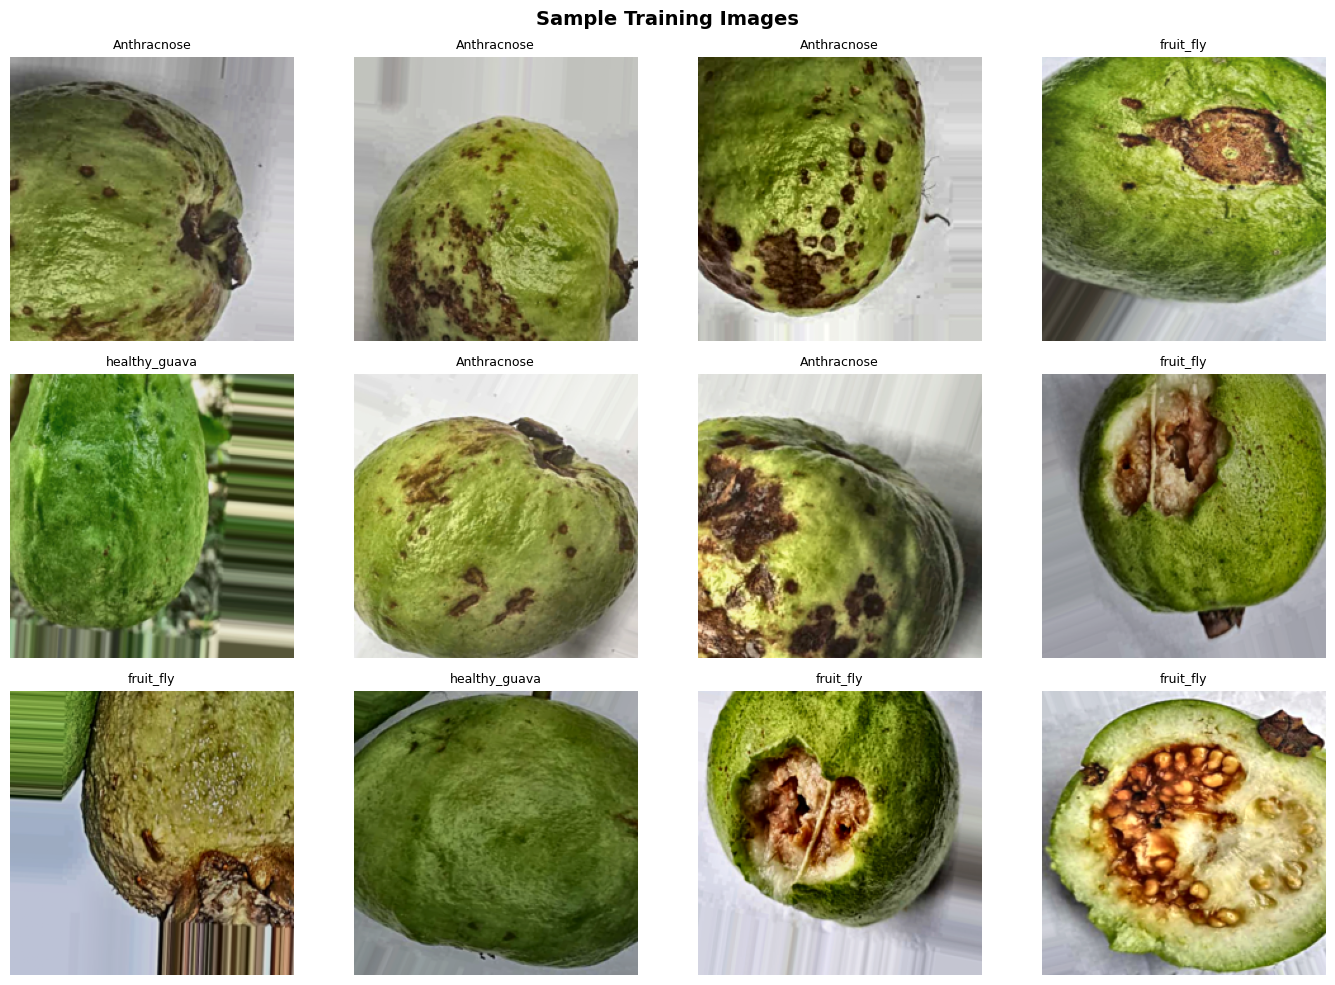

In [17]:
def denormalize(tensor):
    """Undo ImageNet normalisation so the image looks correct when displayed."""
    mean = torch.tensor(MEAN).view(3, 1, 1)
    std  = torch.tensor(STD).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)

# Grab one batch
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
fig.suptitle("Sample Training Images", fontsize=14, fontweight="bold")

for i, ax in enumerate(axes.flat):
    if i >= len(images):
        ax.axis("off")
        continue
    img = denormalize(images[i]).permute(1, 2, 0).numpy()  # (C,H,W) → (H,W,C)
    ax.imshow(img)
    ax.set_title(CLASS_NAMES[labels[i].item()], fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [18]:
# Load pretrained ViT — downloads weights automatically on first run
model = timm.create_model(
    "vit_base_patch16_224",
    pretrained=True,
    num_classes=NUM_CLASSES   # timm replaces the head for us
)

model = model.to(device)

# Confirm the head was replaced correctly
print("Classification head:", model.head)
# Should print: Linear(in_features=768, out_features=3, bias=True)

# Quick check: forward pass with a dummy image
with torch.no_grad():
    dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(device)
    out   = model(dummy)
print(f"Output shape: {out.shape}")   # should be torch.Size([2, 3])

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

Classification head: Linear(in_features=768, out_features=3, bias=True)
Output shape: torch.Size([2, 3])
Total parameters: 85,800,963


In [19]:
# CrossEntropyLoss is standard for multi-class classification
criterion = nn.CrossEntropyLoss()

# AdamW with different learning rates:
#   backbone (pretrained layers) → small LR so we don't destroy learned features
#   head (new layer we added)    → larger LR so it learns quickly
head_params     = list(model.head.parameters())
head_ids        = {id(p) for p in head_params}
backbone_params = [p for p in model.parameters() if id(p) not in head_ids]

optimizer = optim.AdamW([
    {"params": backbone_params, "lr": 1e-5},   # gentle fine-tune
    {"params": head_params,     "lr": 1e-4},   # faster learning for new head
], weight_decay=1e-4)

print("Loss      : CrossEntropyLoss")
print("Optimizer : AdamW  (backbone lr=1e-5 | head lr=1e-4)")

Loss      : CrossEntropyLoss
Optimizer : AdamW  (backbone lr=1e-5 | head lr=1e-4)


In [20]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """Run one training epoch. Returns average loss and accuracy."""
    model.train()          # enables dropout etc.
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()          # clear old gradients
        outputs = model(images)        # forward pass
        loss    = criterion(outputs, labels)

        loss.backward()                # compute gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # prevent exploding gradients
        optimizer.step()               # update weights

        total_loss += loss.item() * images.size(0)
        preds       = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

    return total_loss / total, correct / total


def validate(model, loader, criterion, device):
    """Run one validation epoch. Returns average loss and accuracy."""
    model.eval()           # disables dropout etc.
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():  # no gradient computation needed
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs    = model(images)
            loss       = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            preds       = outputs.argmax(dim=1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)

    return total_loss / total, correct / total


print("train_one_epoch() and validate() are ready.")

train_one_epoch() and validate() are ready.


In [21]:
NUM_EPOCHS = 10
best_val_acc = 0.0
best_model_path = "/kaggle/working/best_vit_guava.pth"

# Dictionaries to record metrics for plotting later
history = {"train_loss": [], "val_loss": [],
           "train_acc":  [], "val_acc":  []}

print(f"{'Epoch':<7} {'Train Loss':<13} {'Train Acc':<12} {'Val Loss':<12} {'Val Acc':<10}")
print("-" * 58)

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss,   val_acc   = validate(model, val_loader, criterion, device)

    # Record history
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"{epoch:<7} {train_loss:<13.4f} {train_acc:<12.4f} {val_loss:<12.4f} {val_acc:.4f}")

    # Save the model if validation accuracy improved
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"         ✔  Saved best model (val_acc={best_val_acc:.4f})")

print(f"\nTraining complete. Best validation accuracy: {best_val_acc:.4f}")

Epoch   Train Loss    Train Acc    Val Loss     Val Acc   
----------------------------------------------------------
1       0.1326        0.9509       0.0013       1.0000
         ✔  Saved best model (val_acc=1.0000)
2       0.0150        0.9951       0.0013       0.9987
3       0.0038        0.9985       0.0068       0.9974
4       0.0034        0.9985       0.0062       0.9974
5       0.0029        0.9989       0.0002       1.0000
6       0.0058        0.9981       0.0000       1.0000
7       0.0004        1.0000       0.0020       0.9987
8       0.0000        1.0000       0.0000       1.0000
9       0.0000        1.0000       0.0000       1.0000
10      0.0000        1.0000       0.0006       1.0000

Training complete. Best validation accuracy: 1.0000


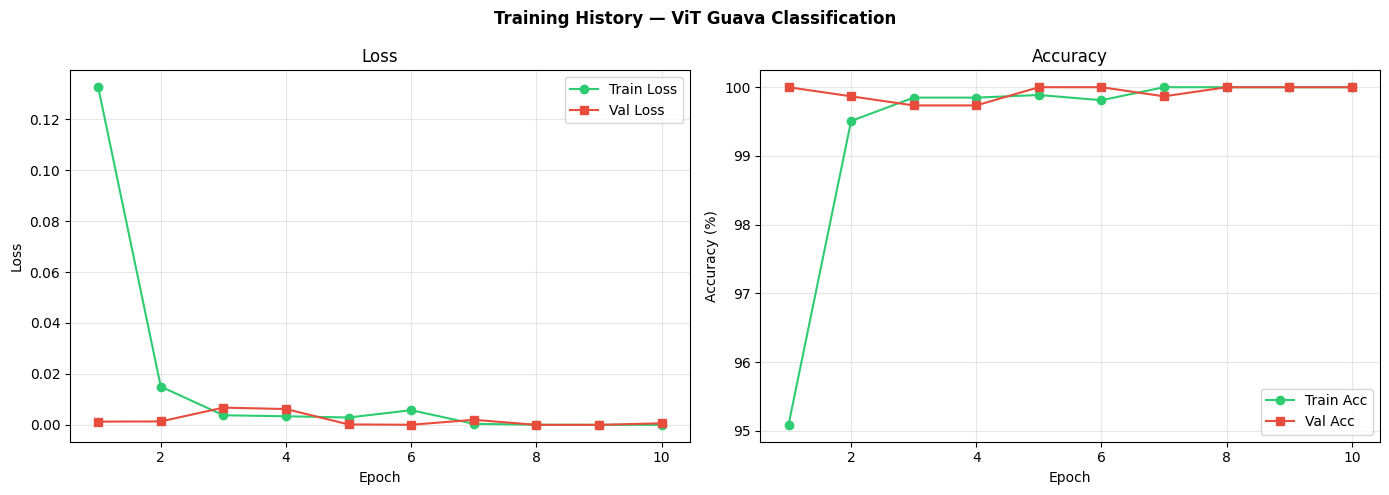

In [22]:
epochs = range(1, NUM_EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Training History — ViT Guava Classification", fontweight="bold")

# ── Loss ──────────────────────────────────────────────────────────────────────
ax1.plot(epochs, history["train_loss"], marker="o", label="Train Loss", color="#2ecc71")
ax1.plot(epochs, history["val_loss"],   marker="s", label="Val Loss",   color="#e74c3c")
ax1.set_title("Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

# ── Accuracy ──────────────────────────────────────────────────────────────────
ax2.plot(epochs, [a * 100 for a in history["train_acc"]], marker="o",
         label="Train Acc", color="#2ecc71")
ax2.plot(epochs, [a * 100 for a in history["val_acc"]],   marker="s",
         label="Val Acc",   color="#e74c3c")
ax2.set_title("Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/training_curves.png", dpi=150)
plt.show()

In [23]:
# Load the best weights saved during training
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds   = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = (all_preds == all_labels).mean()
print(f"Test Accuracy: {test_acc * 100:.2f}%")

Test Accuracy: 100.00%


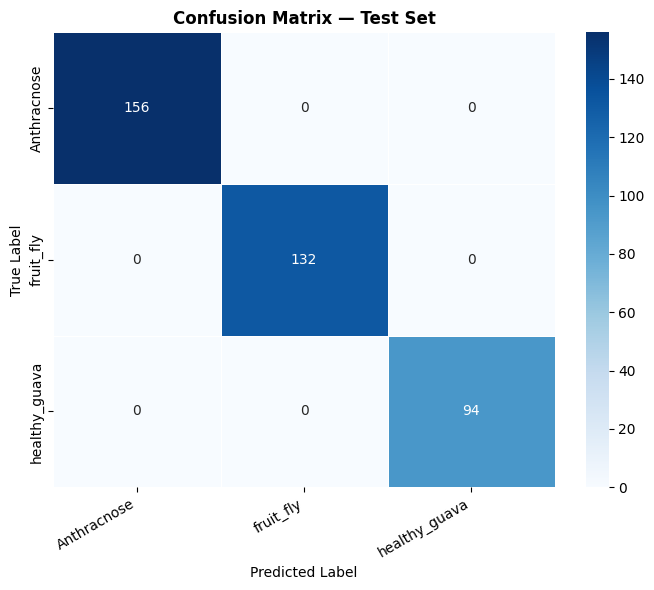


Classification Report:
               precision    recall  f1-score   support

  Anthracnose     1.0000    1.0000    1.0000       156
    fruit_fly     1.0000    1.0000    1.0000       132
healthy_guava     1.0000    1.0000    1.0000        94

     accuracy                         1.0000       382
    macro avg     1.0000    1.0000    1.0000       382
 weighted avg     1.0000    1.0000    1.0000       382



In [24]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True, fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    linewidths=0.5
)
plt.title("Confusion Matrix — Test Set", fontweight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix.png", dpi=150)
plt.show()

# ── Classification report ─────────────────────────────────────────────────────
print("\nClassification Report:")
print(classification_report(all_labels, all_preds,
                             target_names=CLASS_NAMES, digits=4))

In [25]:
import os

# Check the file was saved
if os.path.exists(best_model_path):
    size_mb = os.path.getsize(best_model_path) / (1024 * 1024)
    print(f"Best model saved at : {best_model_path}")
    print(f"File size           : {size_mb:.1f} MB")
else:
    print("Model file not found — check training cell ran correctly.")

# ── How to reload the model later ────────────────────────────────────────────
# model = timm.create_model("vit_base_patch16_224",
#                            pretrained=False,
#                            num_classes=3)
# model.load_state_dict(torch.load(best_model_path, map_location=device))
# model = model.to(device)
# model.eval()
print("\nTo reload this model in a new session, use the commented code above.")

Best model saved at : /kaggle/working/best_vit_guava.pth
File size           : 327.4 MB

To reload this model in a new session, use the commented code above.


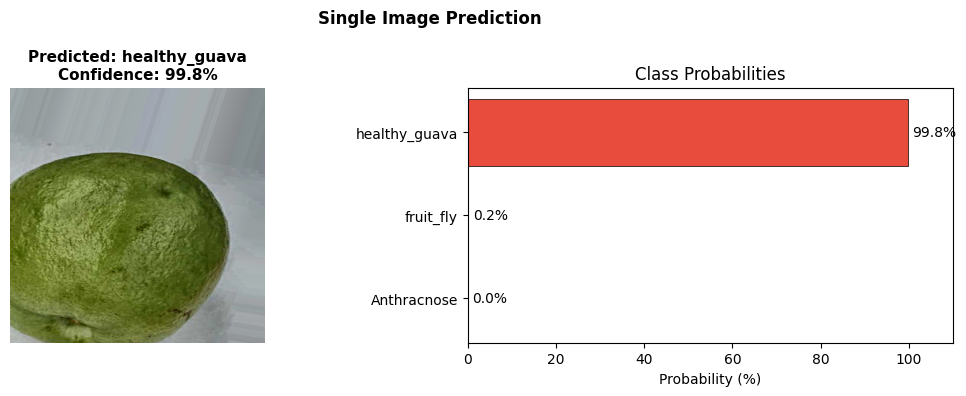


Result → Class: healthy_guava  |  Confidence: 99.83%


In [26]:
def predict_image(image_path, model, transforms_pipeline, idx_to_class, device):
    """
    Predict the class of a single image and display the result.

    Args:
        image_path        : full path to the image file
        model             : trained model in eval() mode
        transforms_pipeline: the val/test transform pipeline
        idx_to_class      : dict mapping integer index → class name
        device            : cuda or cpu
    """
    # Load image and apply preprocessing
    img = Image.open(image_path).convert("RGB")
    tensor = transforms_pipeline(img).unsqueeze(0).to(device)  # add batch dim

    model.eval()
    with torch.no_grad():
        logits = model(tensor)                          # raw scores
        probs  = torch.softmax(logits, dim=1)[0]        # probabilities
        pred_idx = probs.argmax().item()

    pred_class  = idx_to_class[pred_idx]
    confidence  = probs[pred_idx].item()

    # ── Display ────────────────────────────────────────────────────────────────
    fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(11, 4))
    fig.suptitle("Single Image Prediction", fontweight="bold")

    ax_img.imshow(img)
    ax_img.set_title(f"Predicted: {pred_class}\nConfidence: {confidence*100:.1f}%",
                     fontsize=11, fontweight="bold")
    ax_img.axis("off")

    colors = ["#3498db"] * len(idx_to_class)
    colors[pred_idx] = "#e74c3c"   # highlight the predicted class in red
    class_labels = [idx_to_class[i] for i in range(len(idx_to_class))]

    ax_bar.barh(class_labels, [probs[i].item() * 100 for i in range(len(idx_to_class))],
                color=colors, edgecolor="black", linewidth=0.5)
    ax_bar.set_xlabel("Probability (%)")
    ax_bar.set_title("Class Probabilities")
    ax_bar.set_xlim(0, 110)

    for i, p in enumerate(probs):
        ax_bar.text(p.item() * 100 + 1, i, f"{p.item()*100:.1f}%", va="center")

    plt.tight_layout()
    plt.show()

    return pred_class, confidence


# ── Example usage ──────────────────────────────────────────────────────────────
# Change this path to any image from your test folder
sample_path = "/kaggle/input/datasets/habibsalehinshamun/guavadiseasedataset-cnn/GuavaDiseaseDataset/test/healthy_guava/100_unsharp_clahe_augmented_6.png"

predicted_class, conf = predict_image(
    sample_path, model, val_test_transforms, idx_to_class, device
)
print(f"\nResult → Class: {predicted_class}  |  Confidence: {conf*100:.2f}%")